In [1]:
import pandas as pd

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
BRT_RESULTS_PATH = "../data/results/final/biored_test/biored_test_results.json"
CBC_RESULTS_PATH = "../data/results/final/contemporary/contemporary_results.json"
METRICS = ["precision", "recall", "f1"]

with open(BRT_RESULTS_PATH, "r") as f:
    brt_results = json.load(f)

with open(CBC_RESULTS_PATH, "r") as f:
    cbc_results = json.load(f)

In [5]:
DATASET_LABELS = {"biored_test": "BioRED Test", "contemporary": "CBC"}

BAR_PALETTE = ["#363636", "#bfbfbf"]
BAR_HATCHES = ["", "//", "xx"]

FIGURE_DIR = Path("../img/generalisation_evaluation")

def plot_generalisation(brt, cbc, category: str, save: bool = False) -> None:
    data = {
        "biored_test": brt_results,
        "contemporary": cbc_results
    }

    datasets = list(data.keys())
    x = np.arange(len(METRICS))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, dataset in enumerate(datasets):
        point = data[dataset][category]["point_estimate"]
        ci = data[dataset][category]["ci"]

        values = [point[m] for m in METRICS]
        lo_err = [point[m] - ci[m][0] for m in METRICS]
        hi_err = [ci[m][1] - point[m] for m in METRICS]

        offset = (i - 0.5) * width
        bars = ax.bar(
            x + offset, values, width,
            yerr=[lo_err, hi_err], capsize=4,
            label=DATASET_LABELS.get(dataset, dataset),
            color=BAR_PALETTE[i],
            edgecolor="black", linewidth=0.5
        )

        for bar in bars:
            bar.set_hatch(BAR_HATCHES[i])
            bar.set_edgecolor("black")

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in METRICS], fontsize=13)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Score", fontsize=14)
    ax.set_title(f"{category.capitalize()} Generalisation: BioRED Test vs. CBC", fontsize=15)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.grid(axis="y", color="black", alpha=0.2)
    ax.set_axisbelow(True)

    ax.legend(fontsize=12)
    fig.tight_layout()

    if save:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIGURE_DIR / f"{category}_generalisation.png", dpi=150)
        print(f"Saved {category}_generalisation.png")

Saved entity_generalisation.png


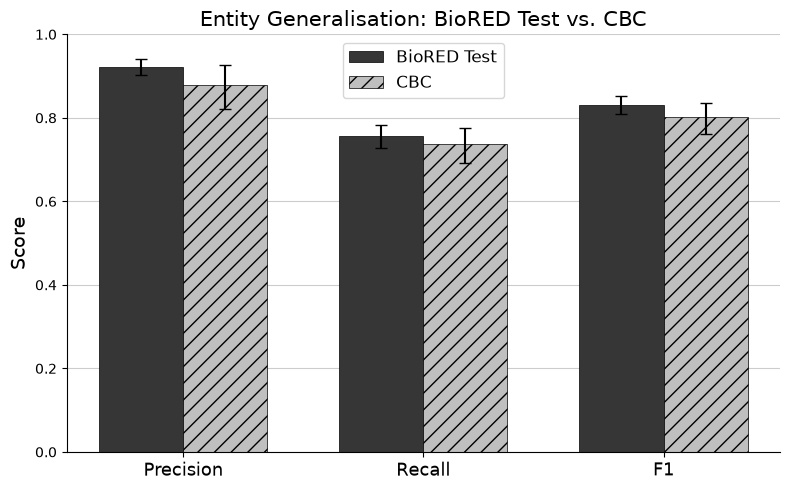

In [6]:
plot_generalisation(cbc_results, brt_results, "entity", save=True)

Saved relation_generalisation.png


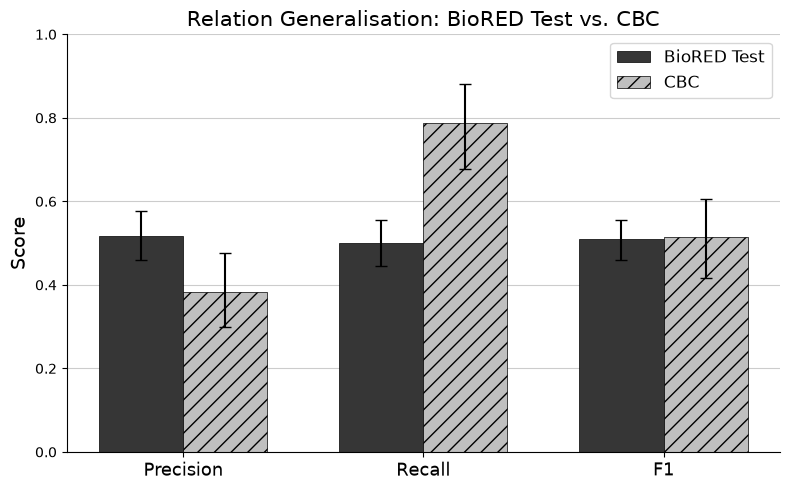

In [7]:
plot_generalisation(cbc_results, brt_results, "relation", save=True)